In [1]:
# Cell 1: 
!pip install pandas matplotlib seaborn

In [2]:
# Cell 2:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# --- Pandas 顯示設定 ---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# --- Matplotlib/Seaborn 中文顯示設定 (適用於 Mac) ---
sns.set(style="whitegrid", context="talk")

try:
    plt.rcParams['font.sans-serif'] = ['PingFang HK']
    plt.rcParams['axes.unicode_minus'] = False 
    print("中文字型設定完成 (PingFang HK)。")
except Exception:
    try:
        plt.rcParams['font.sans-serif'] = ['Heiti TC']
        plt.rcParams['axes.unicode_minus'] = False
        print("備援字型設定完成 (Heiti TC)。")
    except:
        print("所有備援中文字型均失敗。圖表中的中文可能無法顯示。")

中文字型設定完成 (PingFang HK)。


In [3]:
# Cell 3:
start_time = time.time()
print("--- 正在載入 news_snapshot_log.csv ---")
print("這可能會需要幾分鐘，請稍候...")

CSV_PATH = 'news_snapshot_log.csv'

try:
    # 關鍵：我們「不要」在這裡 parse_dates
    # 因為日期格式是混亂的 (v11 vs 舊版)
    # 我們將手動處理
    df_snapshot = pd.read_csv(
        CSV_PATH, 
        on_bad_lines='skip' # 跳過 CSV 中毀損的資料行
    )
    
    end_time = time.time()
    print(f"\n✅ 成功載入資料！耗時: {end_time - start_time:.2f} 秒")
    print(f"   (共 {len(df_snapshot)} 筆原始快照)")

except FileNotFoundError:
    print(f"🔥 錯誤：找不到檔案 '{CSV_PATH}'。請確認檔案名稱與路徑是否正確。")
except Exception as e:
    print(f"🔥 載入時發生未知錯誤: {e}")

--- 正在載入 news_snapshot_log.csv ---
這可能會需要幾分鐘，請稍候...

✅ 成功載入資料！耗時: 0.46 秒
   (共 44341 筆原始快照)


In [4]:
# Cell 4:
if 'df_snapshot' in locals():
    print("--- (1/2) 資料概況 (info) ---")
    # .info() 會顯示每一欄的資料型態及缺失值數量
    df_snapshot.info()

    print("\n--- (2/2) 資料範例 (head) ---")
    # .head() 顯示前 5 筆資料
    display(df_snapshot.head())
else:
    print("🔥 錯誤：'df_snapshot' 尚未成功載入。請先執行 Cell 3。")

--- (1/2) 資料概況 (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44341 entries, 0 to 44340
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             44341 non-null  object
 1   title           44341 non-null  object
 2   content         44341 non-null  object
 3   source          44341 non-null  object
 4   published_at    44341 non-null  object
 5   scraped_at      44341 non-null  object
 6   headline_level  44341 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 2.4+ MB

--- (2/2) 資料範例 (head) ---


,url,title,content,source,published_at,scraped_at,headline_level
0,https://www.nownews.com/news/6749796,任容萱認了單身！首證實情斷5年圈外男友：盼給對方隱私空間,女星任容萱今（3）日出席三立記者會，與電視劇《愛鄰洗衣店》的柯叔元、曹佑寧、禾羽及多位劇組演員共同亮相，除了澄清姊姊Selina的二胎傳聞，任容萱更在受訪時首度證實，與圈外男友已分手，她表示目...,NOWNEWS,2025/11/3 18:00,00:05.5,3
1,https://www.nownews.com/news/6749824,新颱風恐再生成！氣象署：路徑「可能靠近台灣」 濕涼天氣到周三,海鷗颱風路徑往西，對台灣無影響，中央氣象署預報員曾昭誠表示，\n菲律賓東方海面有新熱帶系統發展，不排除生成颱風，下週二至週四（11月11日至13日）可能接近台灣\n；周三（11月5日）前北部、...,NOWNEWS,2025/11/3 18:00,00:05.5,3
2,https://www.nownews.com/news/6749765,屠穎跑步機上跌倒驟逝！遺體確定不包機運回台 今廣州火化歸仙,知名金曲音樂人屠穎本月1日猝逝，享年62歲。他是在中國廣州健身房跑步機運動時，不幸跌倒撞到頭顱內出血過世，消息一出震驚樂壇。他的粉絲紛紛發起捐款，希望可以讓他的遺體透過包機方式回台，不過昨（2...,NOWNEWS,2025/11/3 18:00,00:05.5,3
3,https://www.nownews.com/news/6490678,聽新聞APP裝這款就對了！《NOWnews》AI朗讀 掌握新聞不用再低頭,每天新聞這麼多，想一一看完費時又傷眼力，長時間使用手機、平板等行動裝置，不只會滑出乾眼症、近視加深，也提升視網膜剝離及失明的風險，嚴重會失明！不過，安裝《NOWnews》APP即可透過強大「聽...,NOWNEWS,2025/11/3 18:00,00:05.5,3
4,https://www.nownews.com/news/6749810,日本熊害又奪1命！秋田縣黑熊「大量發生中」 老婦採菇遭襲身亡,日本熊害大爆發，東北地區民宅及人群聚集處大量出現熊的蹤跡，今(3)日一名秋田縣老婦的遺體被發現在山區，疑似遭熊襲身亡，秋田縣今日單日就至少有3例傷亡案件，4起熊目擊和捕獲事件。\n根據共同社報...,NOWNEWS,2025/11/3 18:00,00:05.5,3


In [5]:
# Cell 5:
if 'df_snapshot' in locals():
    print(f"--- 清理前 ---")
    print(f"總快照筆數: {len(df_snapshot)}")
    
    # 1. 將爬蟲產生的 'N/A' 字串轉換為真正的空值 (NA)
    df_snapshot.replace('N/A', pd.NA, inplace=True)
    
    # 2. 【關鍵】保護 L3 資料
    print("正在分離 L3 資料...")
    # 確保 headline_level 是數字
    df_snapshot['headline_level'] = pd.to_numeric(df_snapshot['headline_level'], errors='coerce')
    
    # 將 L3 資料先取出來保護 (即使 content 為 N/A)
    df_l3 = df_snapshot[df_snapshot['headline_level'] == 3.0].copy()
    print(f" -> 已保護 {len(df_l3)} 筆 L3 快照 (即使它們的 content 或 date 損毀)。")
    
    # 3. 清理 L1, L2 與其他資料
    print("正在清理 L1, L2 與其他資料...")
    df_other = df_snapshot[df_snapshot['headline_level'] != 3.0].copy()
    
    # 3a. 移除 L1/L2 中，關鍵欄位為 NA 的資料
    original_len = len(df_other)
    df_other.dropna(subset=['url', 'title', 'content'], inplace=True)
    print(f" -> (L1/L2) 移除了 {original_len - len(df_other)} 筆 (url/title/content 為 N/A 的資料)")

    # 3b. 移除 L1/L2 中，內容過短的資料
    original_len = len(df_other)
    min_content_length = 50
    df_other['content'] = df_other['content'].astype(str) 
    df_other = df_other[df_other['content'].str.len() >= min_content_length]
    print(f" -> (L1/L2) 移除了 {original_len - len(df_other)} 筆 (content 長度 < {min_content_length} 的資料)")

    # 4. 將保護的 L3 資料與清理後的 L1/L2 資料合併回來
    df_cleaned = pd.concat([df_l3, df_other], ignore_index=True)
    print(f" -> 合併 L3 ({len(df_l3)}) 與 L1/L2 ({len(df_other)}) 資料...")
    
    # 5. 移除「完全重複」的快照
    original_len = len(df_cleaned)
    df_cleaned.drop_duplicates(inplace=True)
    print(f" -> 移除了 {original_len - len(df_cleaned)} 筆 (完全重複的快照)")
    
    print(f"\n--- 清理後 ---")
    print(f"剩餘快照筆數: {len(df_cleaned)}")
    
else:
    print("🔥 錯誤：'df_snapshot' 尚未成功載入。請先執行 Cell 3。")

--- 清理前 ---
總快照筆數: 44341
正在分離 L3 資料...
 -> 已保護 9704 筆 L3 快照 (即使它們的 content 或 date 損毀)。
正在清理 L1, L2 與其他資料...
 -> (L1/L2) 移除了 0 筆 (url/title/content 為 N/A 的資料)
 -> (L1/L2) 移除了 0 筆 (content 長度 < 50 的資料)
 -> 合併 L3 (9704) 與 L1/L2 (34637) 資料...
 -> 移除了 4 筆 (完全重複的快照)

--- 清理後 ---
剩餘快照筆數: 44337


In [8]:
# # Cell 5.5:
# if 'df_cleaned' in locals():
#     print("--- 正在手動轉換日期欄位 (published_at, scraped_at) ---")
#     print("   [終極妥協模式]：")
    
#     # 1. 處理 published_at (格式較亂，使用 'coerce')
#     df_cleaned['published_at'] = pd.to_datetime(df_cleaned['published_at'], errors='coerce')
    
#     # 2. 處理 scraped_at (格式混亂)
#     #    我們只接受 v11 腳本 的正確格式 (YYYY-MM-DD HH:MM:SS.f)
#     v11_format = "%Y-%m-%d %H:%M:%S.%f"
    
#     df_cleaned['scraped_at'] = pd.to_datetime(
#         df_cleaned['scraped_at'], 
#         format=v11_format,  # 嚴格匹配 v11 格式
#         errors='coerce'     # 任何不符的 (含 44:22.1) 都設為 NaT
#     )
    
#     # 3. 檢查成果
#     valid_dates_count = df_cleaned['scraped_at'].notna().sum()
#     invalid_dates_count = df_cleaned['scraped_at'].isna().sum()

#     print(f"✅ 轉換完成。")
#     print(f"    -> 成功解析 {valid_dates_count} 筆「v11 格式」的日期 (包含 11/10 之前和之後的)。")
#     print(f"    -> 忽略了 {invalid_dates_count} 筆「舊爬蟲格式」(如 44:22.1) 的日期。")

#     # 【重要】我們「不會」刪除 NaT，因為 L3 樣本要保留
    
#     print("\n--- 轉換後的資料概況 (info) ---")
#     df_cleaned.info()
# else:
#     print("🔥 錯誤：'df_cleaned' 尚未成功產生。請先執行 Cell 5。")

--- 正在執行探索性資料分析 (EDA) [快照層級] ---

[分析 1: 資料範圍] (警告：找不到任何格式正確的日期)

[分析 2: 各媒體快照數量 (Source)]


source
SETN       36950
NOWNEWS     5876
TVBS        1511
Name: count, dtype: int64

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_99128/553671232.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='source', order=source_counts.index, palette="viridis")


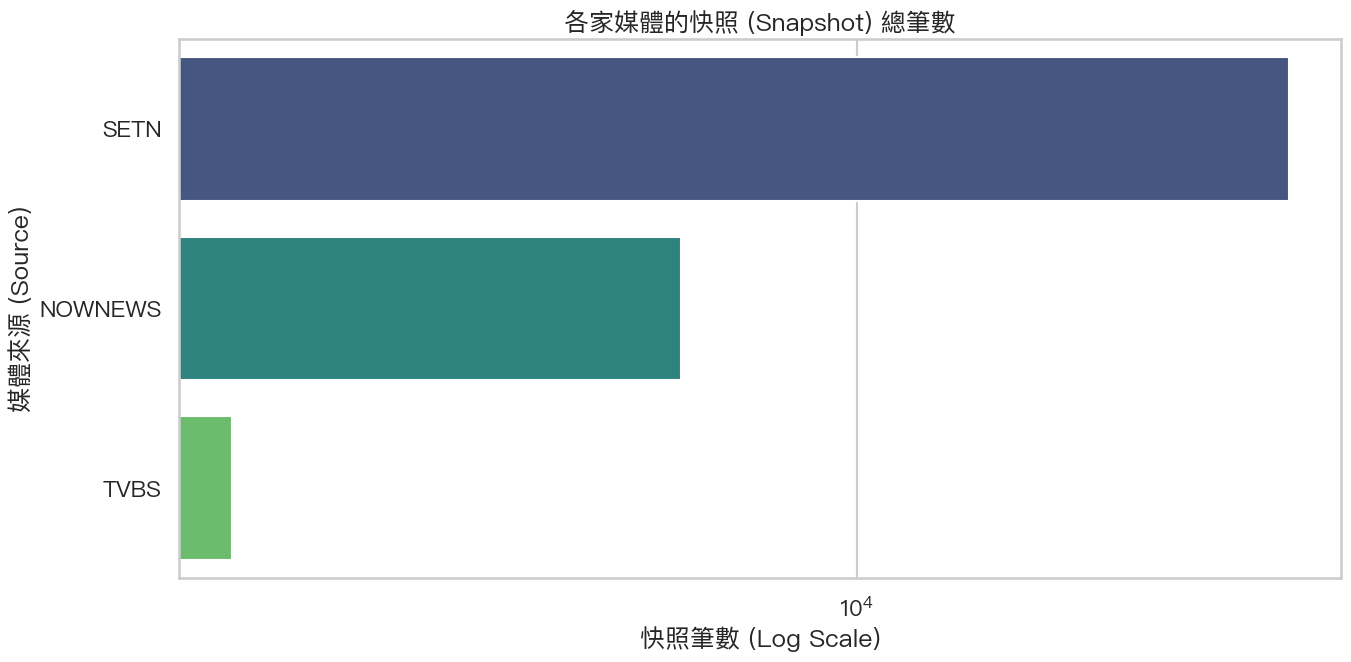


[分析 3: 頭條等級分佈 (Headline Level)]


,筆數,百分比 (%)
headline_level,,
1,29022,65.46
3,9704,21.89
2,5611,12.66


/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_99128/553671232.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, palette="rocket")


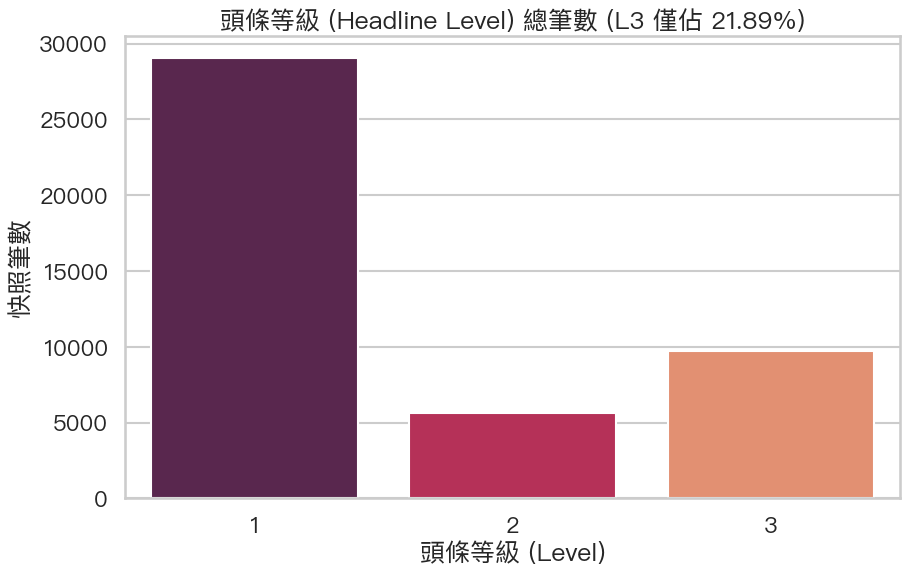

In [9]:
# Cell 6:
if 'df_cleaned' in locals():
    print("--- 正在執行探索性資料分析 (EDA) [快照層級] ---")

    # 1. 資料收集範圍 (只看「有日期」的資料)
    valid_dates = df_cleaned.dropna(subset=['scraped_at'])
    if len(valid_dates) > 0:
        min_time = valid_dates['scraped_at'].min()
        max_time = valid_dates['scraped_at'].max()
        print(f"\n[分析 1: 資料範圍 (僅限有日期的資料)]")
        print(f"資料收集開始時間: {min_time}")
        print(f"資料收集結束時間: {max_time}")
        print(f"總收集天數: {(max_time - min_time).days} 天")
    else:
        print("\n[分析 1: 資料範圍] (警告：找不到任何格式正確的日期)")

    # 2. 各家媒體的快照數量
    print(f"\n[分析 2: 各媒體快照數量 (Source)]")
    source_counts = df_cleaned['source'].value_counts()
    display(source_counts)
    
    plt.figure(figsize=(15, 7))
    sns.countplot(data=df_cleaned, y='source', order=source_counts.index, palette="viridis")
    plt.title('各家媒體的快照 (Snapshot) 總筆數')
    plt.xlabel('快照筆數 (Log Scale)')
    plt.ylabel('媒體來源 (Source)')
    plt.xscale('log')
    plt.show()

    # 3. 頭條等級 (Headline Level) 的分佈
    print(f"\n[分析 3: 頭條等級分佈 (Headline Level)]")
    level_counts = df_cleaned['headline_level'].value_counts()
    level_percent = df_cleaned['headline_level'].value_counts(normalize=True) * 100
    
    display(pd.DataFrame({'筆數': level_counts, '百分比 (%)': level_percent.round(2)}))
    
    # --- 【防呆修正】 ---
    l3_percent = level_percent.get(3.0, 0.0)
    # --- 【修正結束】 ---

    plt.figure(figsize=(10, 6))
    sns.barplot(x=level_counts.index, y=level_counts.values, palette="rocket")
    
    plt.title(f'頭條等級 (Headline Level) 總筆數 (L3 僅佔 {l3_percent:.2f}%)')
    plt.xlabel('頭條等級 (Level)')
    plt.ylabel('快照筆數')
    
    if l3_percent == 0.0:
        print("\n🔥 警告：在您的資料中，L3 (Level 3) 的資料筆數為 0。")
        print("   這表示 L3 爬蟲選擇器已失效，或 L3 資料的 content 是 N/A 且 L3 保護失敗。")
        
    plt.show()

else:
    print("🔥 錯誤：'df_cleaned' 尚未成功產生。請先執行 Cell 5。")

In [10]:
# Cell 7:
if 'df_cleaned' in locals():
    print("--- 正在轉換為「文章生命週期」資料庫 (Article Lifecycle DB) ---")
    print("   [終極妥協模式]：")
    
    start_time = time.time()
    
    # 1. 【關鍵】我們先只彙總「不受時間影響」的欄位
    article_db = df_cleaned.groupby('url').agg(
        title=('title', 'first'),
        content=('content', 'first'),
        source=('source', 'first'),
        published_at=('published_at', 'first'), 
        snapshot_count=('url', 'count'),
        max_headline_level=('headline_level', 'max')
    )
    
    # 2. 【關鍵】我們只針對「有日期」的資料，計算時間
    #    (篩選出那些 scraped_at 不是 NaT 的資料)
    df_with_dates = df_cleaned.dropna(subset=['scraped_at'])
    
    if len(df_with_dates) > 0:
        print(f"   -> 正在為 {len(df_with_dates)} 筆「有日期」的快照計算時間...")
        
        # 計算 first_seen 和 last_seen
        df_times = df_with_dates.groupby('url')['scraped_at'].agg(
            first_seen='min',
            last_seen='max'
        )
        
        # 計算可見時數
        df_times['hours_on_homepage'] = (df_times['last_seen'] - df_times['first_seen']).dt.total_seconds() / 3600
        
        # 3. 將計算好的時間，「合併」回 article_db
        article_db = article_db.merge(df_times, on='url', how='left')
        print("   -> 時間欄位合併完成。")

    else:
        print("   -> 警告：沒有任何資料有合法的日期，無法計算時間。")
        article_db['first_seen'] = pd.NaT
        article_db['last_seen'] = pd.NaT
        article_db['hours_on_homepage'] = np.nan

    
    article_db.reset_index(inplace=True)
    
    end_time = time.time()
    print(f"\n✅ 轉換完成！耗時: {end_time - start_time:.2f} 秒")
    print(f"原始 {len(df_cleaned)} 筆快照，被彙總為 {len(article_db)} 篇獨立文章。")
    
    print("\n--- 「文章生命週期」資料庫範例 (head) ---")
    # 檢查： 'hours_on_homepage' 欄位，舊資料會是 NaN
    display(article_db.head())

else:
    print("🔥 錯誤：'df_cleaned' 尚未成功產生。請先執行 Cell 5。")

--- 正在轉換為「文章生命週期」資料庫 (Article Lifecycle DB) ---
   [終極妥協模式]：
   -> 警告：沒有任何資料有合法的日期，無法計算時間。

✅ 轉換完成！耗時: 0.03 秒
原始 44337 筆快照，被彙總為 4708 篇獨立文章。

--- 「文章生命週期」資料庫範例 (head) ---


,url,title,content,source,published_at,snapshot_count,max_headline_level,first_seen,last_seen,hours_on_homepage
0,https://news.tvbs.com.tw/cars/3039453,特斯拉Roadster開發進度曝光 馬斯克曝2026亮相,有望成為全球最速量產車的Tesla Roadster，即便量產時間一再延宕，原廠高層仍表態新車會在今年底前如期發表。不過，此言似乎與執行長馬斯克一言有所出入，近日在美國舉行的特斯拉股東大會上，...,TVBS,NaT,18,2,NaT,NaT,NaN
1,https://news.tvbs.com.tw/entertainment/3034151,張惠妹傳點頭台東跨年演出 公司證實了,年底將近，跨年舞台的卡司備受注目，目前台東縣長饒慶鈴在臉書發文表示：「再2天，台東跨年晚會最強卡司即將揭曉。」而這句「最強卡司」傳出是天后張惠妹，如果屬實這也是她隔了5年再到台東跨年，對此，張...,TVBS,NaT,1,1,NaT,NaT,NaN
2,https://news.tvbs.com.tw/entertainment/3034410,王子邱勝翊全面停工 喜鵲娛樂聲明道歉,范姜彥豐日前指控老婆粿粿和王子邱勝翊婚內出軌，說她自美國旅遊返台就漸漸不回家，王子隨後發聲承認越界，粿粿則發出17分鐘的影片回擊，糾紛越演越烈。王子所屬的經紀公司「喜鵲娛樂」今（3）日發出聲明...,TVBS,NaT,3,2,NaT,NaT,NaN
3,https://news.tvbs.com.tw/entertainment/3034451,范姜彥豐開撕粿粿首露面 暴瘦11公斤力挺天后闆妹,范姜彥豐日前控訴王子邱勝翊偷吃老婆粿粿，直指粿粿自美國返台就漸漸不太回家，天后闆妹也爆料：「其實那群好友還有一對沒有被爆…唉」雖未指名道姓，但網友都瘋猜與粿王事件有關。天后闆妹今（3）日開直播...,TVBS,NaT,3,2,NaT,NaT,NaN
4,https://news.tvbs.com.tw/entertainment/3034505,黃明志「驚人警局照」曝光 持2包毒品想逃,台灣網紅「護理師女神」謝侑芯在馬來西亞吉隆坡五星級飯店猝逝，歌手黃明志因與她同住酒店過夜被捲入案件，警方從黃明志身上查獲9顆搖頭丸「愛他死」，尿檢呈現4種毒品陽性反應，他已於10月24日被正式...,TVBS,NaT,17,2,NaT,NaT,NaN


--- 正在執行探索性資料分析 (EDA) [文章層級] ---
   [終極妥協模式]：

[分析 1: 最終文章等級分佈 (ML Target Distribution)]


,文章數,百分比 (%)
max_headline_level,,
3.0,4597,50.32
1.0,3073,33.64
2.0,1466,16.05



✅ 成功保留了 4597 篇 L3 文章 (包含舊資料)！


/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_82398/2633817277.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette="inferno")


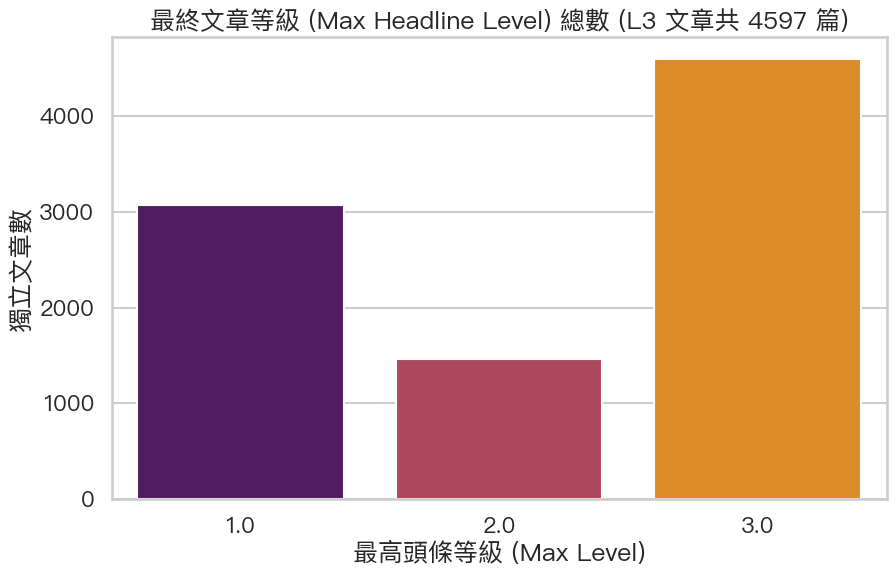


[分析 2: 曾上過 L3 的文章來源]


/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_82398/2633817277.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=l3_source_counts.index, y=l3_source_counts.values, palette="viridis")


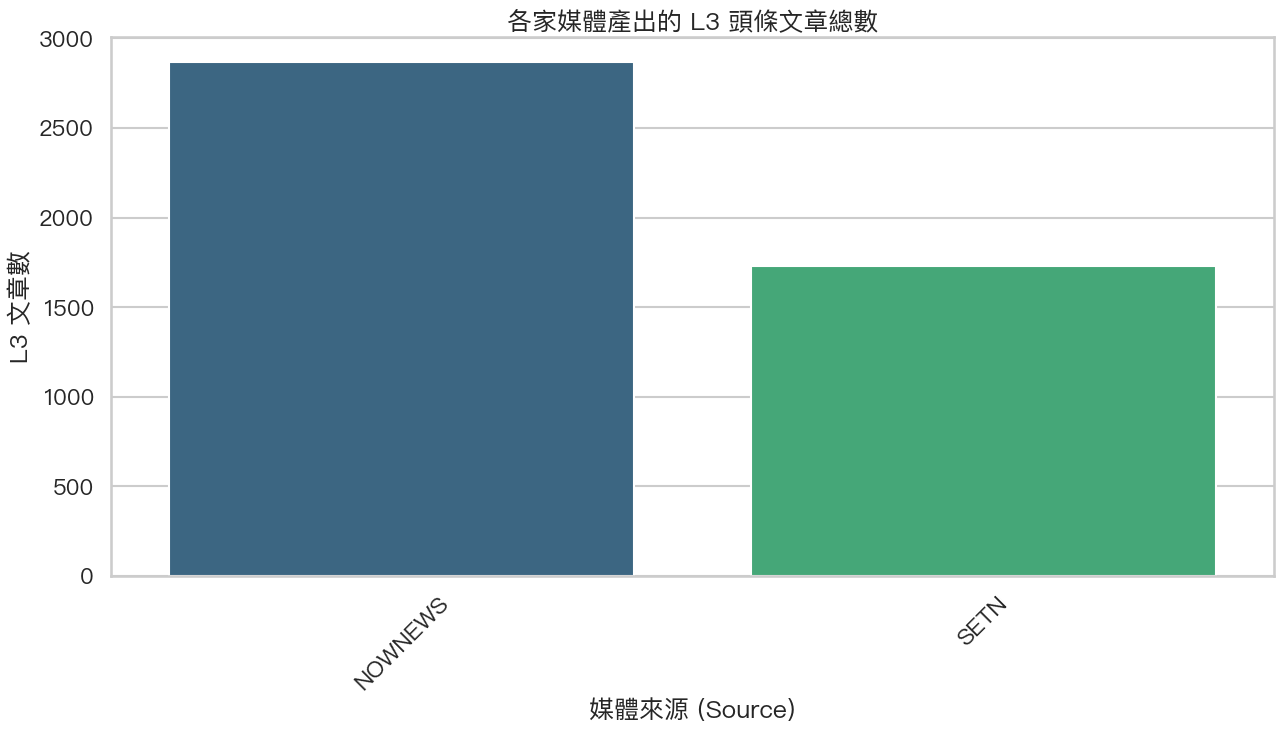


[分析 3: 不同等級文章的平均可見時數 (僅限有日期的資料)]
   (正在分析 4709 篇「有日期」的文章...)


max_headline_level
1.0    12.421116
2.0    11.329837
3.0     8.435981
Name: hours_on_homepage, dtype: float64

/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_82398/2633817277.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hours.index, y=avg_hours.values, palette="coolwarm")


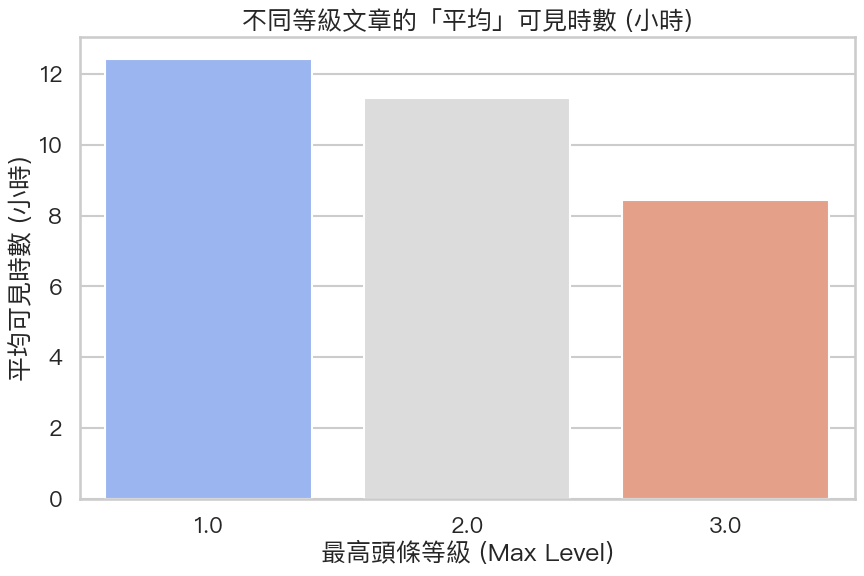

In [9]:
# Cell 8:
if 'article_db' in locals():
    print("--- 正在執行探索性資料分析 (EDA) [文章層級] ---")
    print("   [終極妥協模式]：")

    # 1. 您的「ML 目標變數」分佈 (不受影響)
    print("\n[分析 1: 最終文章等級分佈 (ML Target Distribution)]")
    target_counts = article_db['max_headline_level'].value_counts()
    target_percent = article_db['max_headline_level'].value_counts(normalize=True) * 100
    
    display(pd.DataFrame({'文章數': target_counts, '百分比 (%)': target_percent.round(2)}))
    
    # --- 【防呆修正】 ---
    l3_count = target_counts.get(3.0, 0)
    # --- 【修正結束】 ---

    plt.figure(figsize=(10, 6))
    sns.barplot(x=target_counts.index, y=target_counts.values, palette="inferno")
    plt.title(f'最終文章等級 (Max Headline Level) 總數 (L3 文章共 {l3_count} 篇)')
    plt.xlabel('最高頭條等級 (Max Level)')
    plt.ylabel('獨立文章數')
    
    if l3_count == 0:
        print("\n🔥 警告：L3 文章總數為 0。")
        print("   請務必檢查您的 L3 爬蟲版位選擇器是否失效。")
    else:
        print(f"\n✅ 成功保留了 {l3_count} 篇 L3 文章 (包含舊資料)！")
        
    plt.show()

    # 2. L3 文章的來源分佈 (不受影響)
    print(f"\n[分析 2: 曾上過 L3 的文章來源]")
    l3_articles = article_db[article_db['max_headline_level'] == 3]
    
    if len(l3_articles) == 0:
        print(" -> (無 L3 資料，跳過 L3 來源分析)")
    else:
        l3_source_counts = l3_articles['source'].value_counts()
        plt.figure(figsize=(15, 7))
        sns.barplot(x=l3_source_counts.index, y=l3_source_counts.values, palette="viridis")
        plt.title('各家媒體產出的 L3 頭條文章總數')
        plt.xlabel('媒體來源 (Source)')
        plt.ylabel('L3 文章數')
        plt.xticks(rotation=45)
        plt.show()

    # 3. 不同等級文章的「可見時數」 (只分析「有日期」的資料)
    print(f"\n[分析 3: 不同等級文章的平均可見時數 (僅限有日期的資料)]")
    
    df_with_time = article_db.dropna(subset=['hours_on_homepage'])
    
    if len(df_with_time) > 0 and len(df_with_time[df_with_time['snapshot_count'] > 1]) > 0:
        print(f"   (正在分析 {len(df_with_time)} 篇「有日期」的文章...)")
        avg_hours = df_with_time[df_with_time['snapshot_count'] > 1].groupby('max_headline_level')['hours_on_homepage'].mean()
        display(avg_hours)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=avg_hours.index, y=avg_hours.values, palette="coolwarm")
        plt.title('不同等級文章的「平均」可見時數 (小時)')
        plt.xlabel('最高頭條等級 (Max Level)')
        plt.ylabel('平均可見時數 (小時)')
        plt.show()
    else:
        print(" -> (沒有足夠的「有日期」資料可供分析，請讓爬蟲再多跑幾天)")

else:
    print("🔥 錯誤：'article_db' 尚未成功產生。請先執行 Cell 7。")

In [11]:
# Cell 9:
if 'article_db' in locals():
    OUTPUT_FILENAME = 'article_lifecycle_db.csv'
    print(f"--- <b>正在儲存 [階段二] 成果至 {OUTPUT_FILENAME}</b> ---")
    
    try:
        # 使用 utf-8-sig 確保 Excel 開啟 CSV 時中文不會亂碼
        article_db.to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8-sig')
        print(f"\n✅ 成功儲存！")
        print(f"   這份 '{OUTPUT_FILENAME}' 是一個「混合」資料庫。")
        print(f"   L3 樣本 (無論新舊) 皆被保留。")
        print(f"   只有 v11 爬蟲抓到的資料才會有 'hours_on_homepage' (時間)。")
        
    except Exception as e:
        print(f"🔥 儲存失敗: {e}")

else:
    print("🔥 錯誤：'article_db' 尚未成功產生。請先執行 Cell 7。")

--- <b>正在儲存 [階段二] 成果至 article_lifecycle_db.csv</b> ---

✅ 成功儲存！
   這份 'article_lifecycle_db.csv' 是一個「混合」資料庫。
   L3 樣本 (無論新舊) 皆被保留。
   只有 v11 爬蟲抓到的資料才會有 'hours_on_homepage' (時間)。
